# Trial 1 Explanation

**Questions:** "Can the economic and technical rules of the 2010s predict the explosive growth of the 2020s?"

This also brings up another question because we have averages. It becomes mathematically impossible for the model to "split" the credit: "Did sales go up because the range improved, or because the battery got bigger?"

**Answer:** The answer is **NO**. While training baseline models and time series model, negative R2 score on the test set is the proof. A negative R2 score on the test set means that the model performs worse than simply drawing a flat horizontal line at the average.

This means that the rules changed significantly after covid that using 2011–2019 data as a guide actually misleads the prediction. The 2010s were the "Innovator Phase," while the 2020s are the "Early Majority Phase."

Now, to answer the question "Did sales go up because the range improved, or because the battery got bigger?". There is a correlation between range and battery capacity. In the 2010s, the BEVs were adopted so much, hence the values for them were low, however, they improved with passing time.

So inorder to overcome multicollinearlity but also not lossing information, PCA was used. PCA didn't try to pick between "Range" or "Battery." It groups them into a single "Technical Advancement" factor. Technical Synergy (the combination of all these) is what drove diffusion.

**Trial 1 - Final Outcome**
1. Linear Regression: It expected "straight line" growth. Proves BEV diffusion is non-linear and has entered an exponential phase.

2. SVR: It tried to find a complex curve that fit the 2010s too closely. Proves the 2010s curve was a "False Trend" that does not apply to the new policy landscape.

3. ARIMAX: It used "momentum" from the past. Proves that current growth is not just "more of the same," but a regime shift.

# Trial 2 Explanation

Now since the focus moves from "crisis identification" to "modelling a new reality". So, the question here changes - **"Has a New Diffusion Regime Stabilized?"**

By including the post-COVID era in the training data, we are testing how much history influences the present.

In [111]:
import os
import joblib
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.metrics import silhouette_score
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [112]:
# Open a file upload dialog
uploaded = files.upload()

Saving Cleaned Dataset.csv to Cleaned Dataset (2).csv


In [113]:
dataset = pd.read_csv("Cleaned Dataset.csv")

In [114]:
dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),...,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_Available,Log_DC Recharging Speed (km/h),YJ_Purchase price (EUR)
0,Austria,2011,0.18,631.0,308167.0,3.286579,1.6,963,17.500000,175.000000,...,95.00,30469.93,0.165514,6.448889,6.871091,12.638400,1.455489,1.609438,5.170484,-1.493084
1,Austria,2012,0.13,427.0,316589.4,2.485676,1.0,1063,29.169521,217.394139,...,95.00,30469.93,0.122218,6.059123,6.969791,12.665364,1.248662,1.609438,5.386301,-1.493084
2,Austria,2013,0.21,656.0,321191.7,2.000156,0.4,1173,48.200000,270.000000,...,142.22,30469.93,0.190620,6.487684,7.068172,12.679797,1.098664,2.197225,5.602119,-1.493084
3,Austria,2014,0.44,1344.0,330113.5,1.605812,1.0,1393,22.600000,240.000000,...,155.77,35555.64,0.364643,7.204149,7.239933,12.707195,0.957744,2.639057,5.484797,-0.885657
4,Austria,2015,0.55,1699.0,342083.5,0.896563,0.6,1625,47.700000,381.250000,...,215.22,42052.00,0.438255,7.438384,7.393878,12.742813,0.640043,3.091042,5.946075,0.277809


In [115]:
dataset.columns

Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)'],
      dtype='object')

# Feature Selection

The feature selection is done from 2011-2022 data. This could help us answer a real world hypothesis question - **Is the post-pandemic growth a chaotic, unpredictable anomaly, or has it settled into a "New Normal" with its own set of predictable rules?**

In [116]:
# Split the dataset train and test 
train = dataset[dataset['Year'].between(2011, 2022)].copy()
test = dataset[dataset['Year'].between(2023, 2024)].copy()

In [117]:
features = [
    'Log_Recharging Points',
    'Real Range',
    'Log_Available',
    'YJ_Purchase price (EUR)',
    'AC Recharging Speed (km/h)',
    'Battery Capacity',
    'Log_DC Recharging Speed (km/h)',
    'EG',
    'Log_GDP',
    'Log_CPI'
]

**1. Heat Maps with Pearson Correlation**

Helps in understanding correlation of the features in train data

Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on years from 2011 - 2022:

Log_Available                     0.780202
Real Range                        0.680367
Log_Recharging Points             0.679944
Log_DC Recharging Speed (km/h)    0.678136
Battery Capacity                  0.603266
Log_CPI                           0.357770
YJ_Purchase price (EUR)           0.353438
AC Recharging Speed (km/h)        0.277115
EG                                0.211262
Log_GDP                           0.159132
Name: Log_BEV Percentage (Total Number Of Registrations), dtype: float64


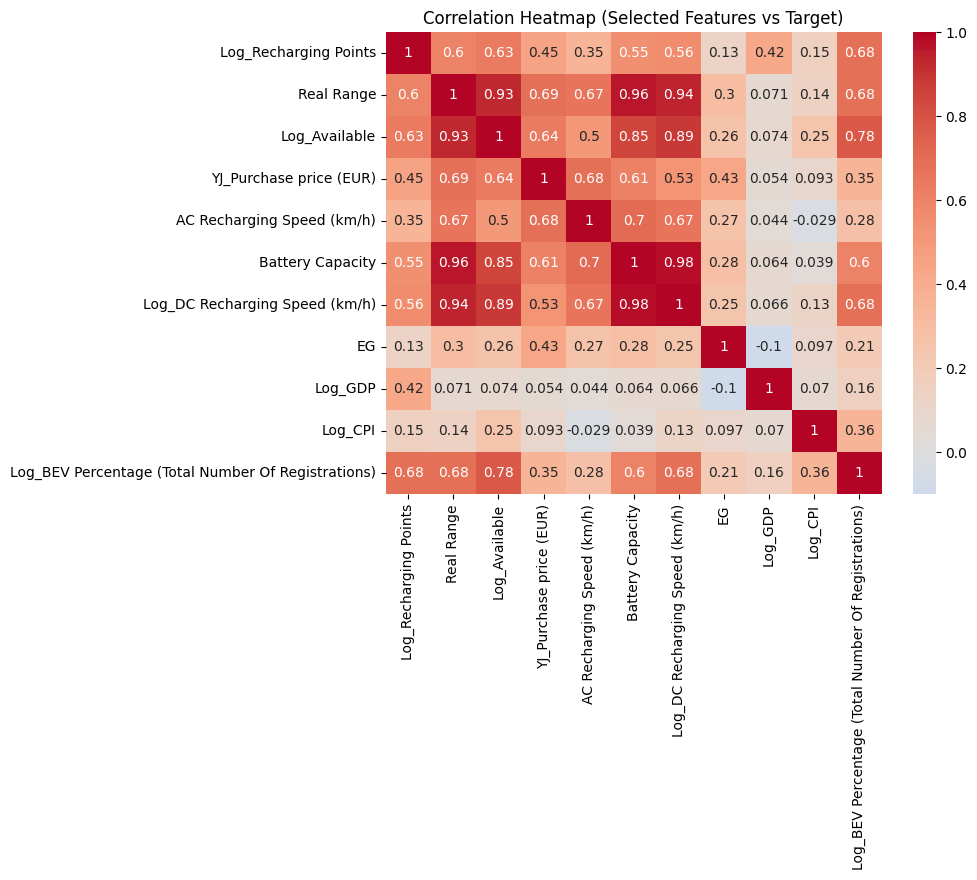

In [118]:
# Define the target
target = 'Log_BEV Percentage (Total Number Of Registrations)'

# Compute correlation only for selected features + target
corr = train[features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)

# Drop the target itself if it appears
corr = corr.drop(labels=[target], errors='ignore')

# Display correlations
print("Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on years from 2011 - 2022:\n")
print(corr)

# Visualize heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train[features + [target]].corr(numeric_only=True),
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Selected Features vs Target)")
plt.show()

In [119]:
train[['Log_BEV Percentage (Total Number Of Registrations)',
         'Log_BEV (New Registrations)']].corr()

,Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations)
Log_BEV Percentage (Total Number Of Registrations),1.000000,0.713372
Log_BEV (New Registrations),0.713372,1.000000


**2. Multicollinearity**

Removal of redundant features

In [120]:
train_features = dataset[features].dropna().reset_index(drop=True)

train_vif_data = pd.DataFrame()
train_vif_data["Feature"] = train_features.columns
train_vif_data["VIF"] = [variance_inflation_factor(train_features.values, i) for i in range(train_features.shape[1])]
print(train_vif_data)

                          Feature         VIF
0           Log_Recharging Points   17.045261
1                      Real Range  537.361825
2                   Log_Available  115.978308
3         YJ_Purchase price (EUR)    4.666438
4      AC Recharging Speed (km/h)   39.427131
5                Battery Capacity  271.273113
6  Log_DC Recharging Speed (km/h)  131.906094
7                              EG    1.782205
8                         Log_GDP   56.511499
9                         Log_CPI    3.290362


**Observation**

A lower VIF values does not guarantee that the feature is highly correlated with the target.

For example: EG with a lower VIF=1.782205 also has a lower correlation values in Heatmaps. **Meaning:** it is unique and not overlapping with other variables. "Unique but Unhelpful" yet we can keep it cause its giving a new perspective.
    
But, Log_Recharging Points with a higher VIF=17.045261 also has the strongest correlation with your target.

Moreover, Battery Capacity with a VIF=271.273113 because it is likely tied to Real Range and Purchase Price and also is has a correlation of 0.6. Its high VIF suggests it might be redundant if you already have Real Range in the model.

**3. Principal Component Analysis (PCA)**

To reduce the dimensions and deal with multicollinearity. This also will help us resolve the conflict of high correlation with sales but also high VIF.

**Refer paper : A Tutorial on Principal Component Analysisn to understand the PCA concept**

## Mathematics For PCA

**Step 1: Covariance Matrix**  
Calculates the covariance matrix for the features to see the relationship among themselves. Since we also have average features like "Real Range" and "Battery Capacity" which go hand in hand as verfied previously using heatmap and VIF.

**Step 2: Eigen Value decomposition and determine Eigen Vectors**
Formula: determinant|(A - $\lambda$.I)| = 0

**Step 3: Normalise the Eigen Vectors**
Point to remember: Discarding the eigenvector v2 and so on, will reduce dimensionality leading to loss of information. Therefore here we used Elbow Method to get the significant eigen vectors to prevent this.

**Step 4: Find the Principal Components**
Here,  the aim is to use the feature vector formed using the eigenvectors of the covariance matrix, to reorient the data from the original axes to the ones represented by the principal components (hence the name Principal Components Analysis).

Formula: Final Dataset = Feature Vector (Step 3) * Normalised Original Dataset (Step 3)

In [121]:
# Check which columns have NaNs and how many
print("Missing Values Per Column on Train data (2011-2022)")
print(train[features].isna().sum())

print("\nMissing Values Per Column Test data (2023-2024)")
print(test[features].isna().sum())

Missing Values Per Column on Train data (2011-2022)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           9
dtype: int64

Missing Values Per Column Test data (2023-2024)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           0
dtype: int64


In [122]:
# Checking which rows are empty
print("Missing Log_CPI in Train data (2011-2022)")
print(train[train['Log_CPI'].isna()].reset_index()[['Country', 'Year', 'Log_CPI']])

Missing Log_CPI in Train data (2011-2022)
    Country  Year  Log_CPI
0  Bulgaria  2014      NaN
1   Croatia  2016      NaN
2    Cyprus  2014      NaN
3    Cyprus  2015      NaN
4    Cyprus  2016      NaN
5    Greece  2014      NaN
6    Greece  2015      NaN
7    Greece  2020      NaN
8   Romania  2016      NaN


In [123]:
# Imputation for Log_CPI NaNs by filling the spaces with the median

# Calculate the median Log_CPI for every country of train data
country_medians = train.groupby('Country')['Log_CPI'].median()

# Function to fill the gaps
def impute_by_country(df):
    df_clean = df.copy()

    # Loop through the data, if Log_CPI is missing, we look up that specific country's median from our 'country_medians' list.
    df_clean['Log_CPI'] = df_clean['Log_CPI'].fillna(df_clean['Country'].map(country_medians))

    return df_clean

# Apply the fix to train dataset
train_fixed = impute_by_country(train)
test_fixed = impute_by_country(test)

# Extract 10 features
X_train_imputed = train_fixed[features]
X_test_imputed = test_fixed[features]

In [124]:
# Verfication
print("Missing Values Per Column on Train data (2011-2022)")
print(train_fixed[features].isna().sum())

print("\nMissing Values Per Column Test data (2023-2024)")
print(test_fixed[features].isna().sum())

Missing Values Per Column on Train data (2011-2022)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           0
dtype: int64

Missing Values Per Column Test data (2023-2024)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           0
dtype: int64


**Reason for imputing with median:** Using a mean here, would technically be incorrect because the years missing is between the time frame 2011-2022 where there is a steady growth an sudden growth post Covid; Mean would pull the value to a higher margin showing a "hyperinflation" out of no where.

The median value ignores those crazy spikes and gives you a much more realistic inflation value for Europe.

In [125]:
# Standard Scaling to bring everything in one unit after imputing the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

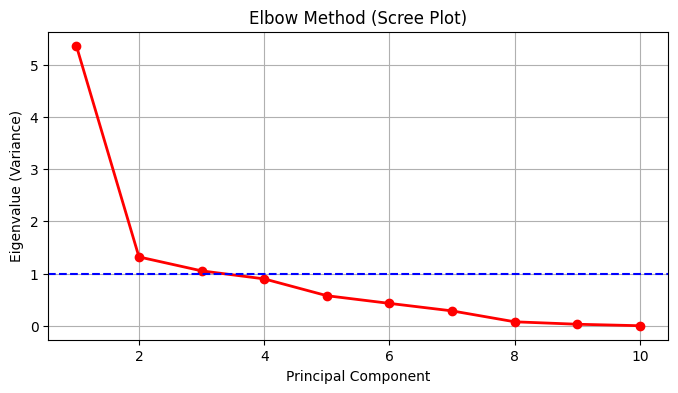

In [126]:
# Elbow Method to justify the number of components
pca_full = PCA() # We fit all 10 components first to see the curve
pca_full.fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'ro-', linewidth=2)
plt.axhline(y=1, color='blue', linestyle='--')
plt.title('Elbow Method (Scree Plot)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.grid(True)
plt.show()

The logic here is we have kept only those eigenvalues which above the "elbow" (or above lambda = 1).

Mathematically discarding the Eigenvectors v4 to v10.

In [127]:
# PCA: fit on Pre-COVID; project Post-COVID into that same space
principal_components = 3 # Based on the elbow method for not missing out on any features
pca = PCA(n_components=principal_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

We calculate the covariance matrix and the Eigen values on the train dataset.
1. This identifies relationship between variables like Real Range and Battery Capacity.
2. The Eigenvalues tell you which patterns were the strongest before the pandemic. For example, if "GDP" was the biggest driver of variance in 2015, the Eigenvector associated with the largest $\lambda$ will point toward GDP.

In [128]:
# Convert to Final Dataset for your Prediction Model
pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

X_train_final = pd.DataFrame(X_train_pca, columns=pc_columns, index=train.index)
X_test_final = pd.DataFrame(X_test_pca, columns=pc_columns, index=test.index)

In [129]:
# Define target
y_train = train['Log_BEV Percentage (Total Number Of Registrations)']
y_test = test['Log_BEV Percentage (Total Number Of Registrations)']

print(f"{len(features)} features reduced to {len(pc_columns)} Principal Components.")
print(f"Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

10 features reduced to 3 Principal Components.
Variance Explained: 77.14%


**For Train:** Python takes the 2011–2022 data and multiplies it by the top 3 Eigenvectors to get the X_train_final coordinates.

**For Test:** Code does not solve $|A - lambda I| = 0 for the Test set. Instead, it takes the Feature Vector (Eigenvectors) discovered in the Training set and multiplies it by the 2023–2024 data. This prevents data leakage.

In [130]:
# Check which PC is the strongest predictor of sales
pc_correlation = X_train_final.corrwith(y_train)
print("Correlation of Principal Components with BEV Sales:")
print(pc_correlation.sort_values(ascending=False))

Correlation of Principal Components with BEV Sales:
PC1    0.687725
PC2    0.268157
PC3    0.227633
dtype: float64


In [131]:
# Features along with their weights in each principal component columns explaining their variance.
loadings_table = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)

# Display the final table
print("Loading factors of the parameters selected (Feature Weights)")
print(loadings_table.round(4))

Loading factors of the parameters selected (Feature Weights)
                                   PC1     PC2     PC3
Log_Recharging Points           0.2937  0.4456 -0.0313
Real Range                      0.4202 -0.0209 -0.0300
Log_Available                   0.3958  0.0639  0.1074
YJ_Purchase price (EUR)         0.3309 -0.1609  0.0581
AC Recharging Speed (km/h)      0.3245 -0.1933 -0.2173
Battery Capacity                0.4090 -0.0605 -0.1375
Log_DC Recharging Speed (km/h)  0.4038 -0.0102 -0.0721
EG                              0.1640 -0.3845  0.3914
Log_GDP                         0.0593  0.7195 -0.1429
Log_CPI                         0.0701  0.2538  0.8592


In [132]:
# To confirm that all the principal components are independent of each other.
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_final.columns

# Calculate VIF for each Principal Component
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i)
                   for i in range(len(X_train_final.columns))]

print("VIF for Principal Components")
print(vif_data)

VIF for Principal Components
  Feature  VIF
0     PC1  1.0
1     PC2  1.0
2     PC3  1.0


In [133]:
# Saving the PCA model
# Define filenames
csv_files = ['X_train_pca.csv', 'X_test_pca.csv', 'y_train.csv', 'y_test.csv']
pkl_file = 'pca_processors.pkl'

# Save the processed Datasets
X_train_final.to_csv(csv_files[0], index=True)
X_test_final.to_csv(csv_files[1], index=True)
y_train.to_csv(csv_files[2], index=True)
y_test.to_csv(csv_files[3], index=True)

# Save the PCA
pca_processing_tools = {
    'country_medians': country_medians,
    'scaler': scaler,
    'pca_model': pca,
    'feature_names': features
}
joblib.dump(pca_processing_tools, pkl_file)

# Just to be sure print the exact file locations
print(f"Folder Location: {os.getcwd()}")
print("-" * 30)

for file in csv_files + [pkl_file]:
    full_path = os.path.abspath(file)
    print(f"Saved: {file}")
    print(f"Full Path: {full_path}\n")

Folder Location: /content
------------------------------
Saved: X_train_pca.csv
Full Path: /content/X_train_pca.csv

Saved: X_test_pca.csv
Full Path: /content/X_test_pca.csv

Saved: y_train.csv
Full Path: /content/y_train.csv

Saved: y_test.csv
Full Path: /content/y_test.csv

Saved: pca_processors.pkl
Full Path: /content/pca_processors.pkl



# Clustering

In [134]:
# Load PCA tools and feature definitions
tools = joblib.load("pca_processors.pkl")

scaler = tools['scaler']
pca = tools['pca_model']
country_medians = tools['country_medians']
features = tools['feature_names']

Understanding train data and test data

In [135]:
train_data = dataset[dataset['Year'].between(2011, 2022)].copy()
test_data = dataset[dataset['Year'].between(2023, 2024)].copy()

In [136]:
# Aggregate numeric features per country
train_country = train_data.groupby('Country')[features].mean(numeric_only=True)
test_country = test_data.groupby('Country')[features].mean(numeric_only=True)

print(f"Train dataset shape: {train_country.shape}")
print(f"Test dataset shape: {test_country.shape}")

Train dataset shape: (27, 10)
Test dataset shape: (27, 10)


1. Each country now appears once per period.
2. Each feature represents that country’s average condition during the period.

In [137]:
# Apply the same scaling and PCA
X_pre_scaled = scaler.transform(train_country)
X_post_scaled = scaler.transform(test_country)

X_pre_pca = pca.transform(X_pre_scaled)
X_post_pca = pca.transform(X_post_scaled)

print(f"PCA-transformed shapes: Train={X_pre_pca.shape}, Test={X_post_pca.shape}")

PCA-transformed shapes: Train=(27, 3), Test=(27, 3)


## 1. K-Means

**Refer paper: Analysis of Techniques for Selecting Appropriate Number of Clusters in k-means Clustering Algorithm** to cite why I chose these 2 methods.

Elbow Method

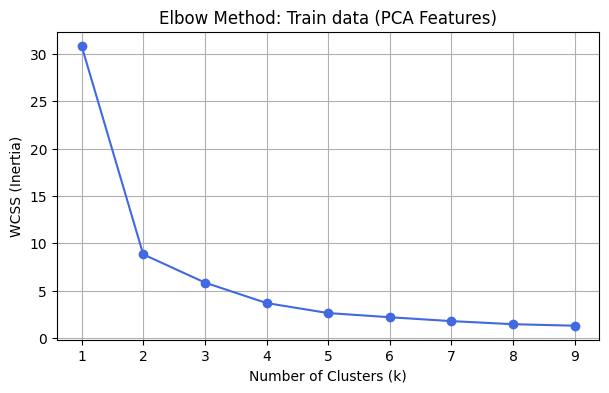

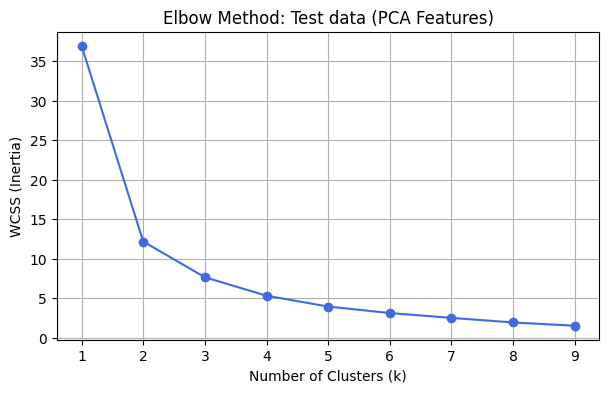

In [138]:
# Elbow Method (to find optimal k)
def plot_elbow(X, label):
    inertia = []
    K_range = range(1, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, inertia, 'o-', color='royalblue')
    plt.title(f'Elbow Method: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.grid(True)
    plt.show()

plot_elbow(X_pre_pca, "Train data (PCA Features)")
plot_elbow(X_post_pca, "Test data (PCA Features)")

Use of SILHOUETTE method to verify the #clusters in eblow method

**This is the validation method to the elbow method.**

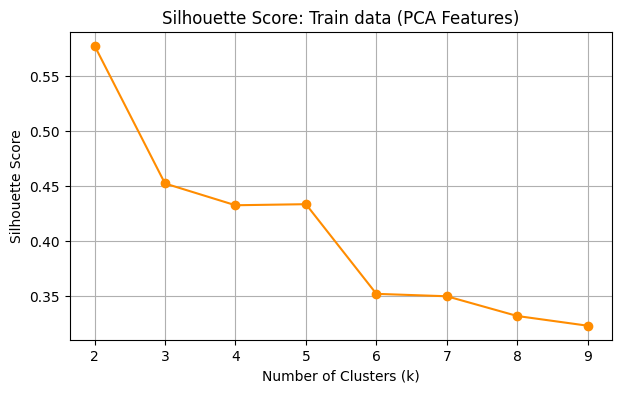

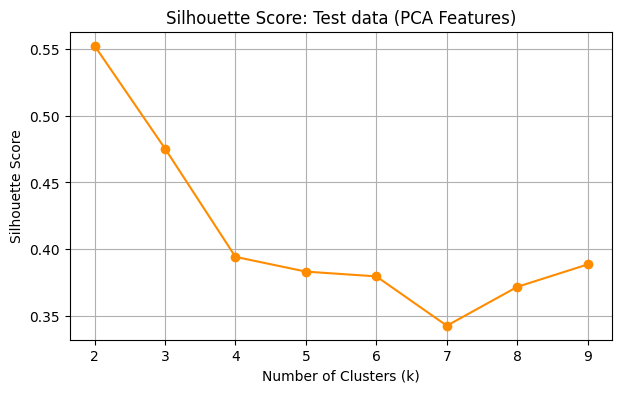

In [139]:
# Silhouette Method (to validate optimal k)
def plot_silhouette(X, label):
    sil_scores = []
    K_range = range(2, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, sil_scores, 'o-', color='darkorange')
    plt.title(f'Silhouette Score: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

plot_silhouette(X_pre_pca, "Train data (PCA Features)")
plot_silhouette(X_post_pca, "Test data (PCA Features)")

In [140]:
# Final Clustering
n_clusters = 2

kmeans_pre = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_post = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

train_country['Cluster'] = kmeans_pre.fit_predict(X_pre_pca)
test_country['Cluster'] = kmeans_post.fit_predict(X_post_pca)

In [141]:
# Compare cluster memberships in both the datasets
cluster_compare = train_country[['Cluster']].rename(columns={'Cluster': 'Train_Cluster'})
cluster_compare['Test_Cluster'] = test_country['Cluster']
print(cluster_compare)

                Train_Cluster  Test_Cluster
Country                                    
Austria                     0             0
Belgium                     0             0
Bulgaria                    1             1
Croatia                     1             1
Cyprus                      1             1
Czech Republic              0             0
Denmark                     0             0
Estonia                     1             1
Finland                     0             0
France                      0             0
Germany                     0             0
Greece                      1             1
Hungary                     0             0
Ireland                     1             1
Italy                       0             0
Latvia                      1             1
Lithuania                   1             1
Luxembourg                  1             1
Malta                       1             1
Netherlands                 0             0
Poland                      0   

In [142]:
# Print which countries changed clusters
print("\nCountries that changed clusters from Train to Test Cluster:\n")
for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Train_Cluster']
    post_c = cluster_compare.loc[c, 'Test_Cluster']
    if pre_c != post_c:
        print(f"  - {c}: {pre_c} ---> {post_c}")


Countries that changed clusters from Train to Test Cluster:

  - Portugal: 0 ---> 1


In [143]:
# Print which stable countries
stable_count = 0

for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Train_Cluster']
    post_c = cluster_compare.loc[c, 'Test_Cluster']

    # If the clusters are the same
    if pre_c == post_c:
        print(f"  - {c}: Stayed in Cluster {pre_c}")
        stable_count += 1

  - Austria: Stayed in Cluster 0
  - Belgium: Stayed in Cluster 0
  - Bulgaria: Stayed in Cluster 1
  - Croatia: Stayed in Cluster 1
  - Cyprus: Stayed in Cluster 1
  - Czech Republic: Stayed in Cluster 0
  - Denmark: Stayed in Cluster 0
  - Estonia: Stayed in Cluster 1
  - Finland: Stayed in Cluster 0
  - France: Stayed in Cluster 0
  - Germany: Stayed in Cluster 0
  - Greece: Stayed in Cluster 1
  - Hungary: Stayed in Cluster 0
  - Ireland: Stayed in Cluster 1
  - Italy: Stayed in Cluster 0
  - Latvia: Stayed in Cluster 1
  - Lithuania: Stayed in Cluster 1
  - Luxembourg: Stayed in Cluster 1
  - Malta: Stayed in Cluster 1
  - Netherlands: Stayed in Cluster 0
  - Poland: Stayed in Cluster 0
  - Romania: Stayed in Cluster 0
  - Slovakia: Stayed in Cluster 1
  - Slovenia: Stayed in Cluster 1
  - Spain: Stayed in Cluster 0
  - Sweden: Stayed in Cluster 0


In [144]:
# Check mean PC scores for each cluster Train data and Test data

# Merge the PCA values back into our country summaries
pre_analysis = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2', 'PC3'], index=train_country.index)
pre_analysis['Cluster'] = train_country['Cluster']

post_analysis = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2', 'PC3'], index=test_country.index)
post_analysis['Cluster'] = test_country['Cluster']

# Print the Centroids characteristics as per the PCA
print("Train Data (2011-2022) Cluster Centroids (Mean PCA Scores)")
print(pre_analysis.groupby('Cluster').mean())
print()
print("Test Data (2023-2024) Cluster Centroids (Mean PCA Scores)")
print(post_analysis.groupby('Cluster').mean())

Train Data (2011-2022) Cluster Centroids (Mean PCA Scores)
              PC1       PC2       PC3
Cluster                              
0        0.155837  0.781446 -0.125720
1       -0.196366 -0.982490  0.137911

Test Data (2023-2024) Cluster Centroids (Mean PCA Scores)
              PC1       PC2       PC3
Cluster                              
0        5.501867  0.929209 -0.269250
1        5.192045 -0.924378  0.114966


**For country that changed the cluster - Portugal**

During the 2010s and the immediate post-COVID boom, Portugal’s infrastructure and economic metrics aligned with high-growth "Leader" nations like Germany and Austria. However, in the most recent 2023–2024 window, Portugal failed to maintain the same pace of infrastructure expansion or economic readiness as other Leaders, causing it to fall back into the "Follower" profile.

In [145]:
# Preparing the data for plotting by ensuring PC scores and Clusters are aligned

# List of unique countries in the correct order
pre_countries_list = train_country.index
post_countries_list = test_country.index

# Create DataFrames for plotting using the PCA results
pre_plot_data = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2', 'PC3'], index=pre_countries_list)
pre_plot_data['Cluster'] = train_country['Cluster']

post_plot_data = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2', 'PC3'], index=post_countries_list)
post_plot_data['Cluster'] = test_country['Cluster']

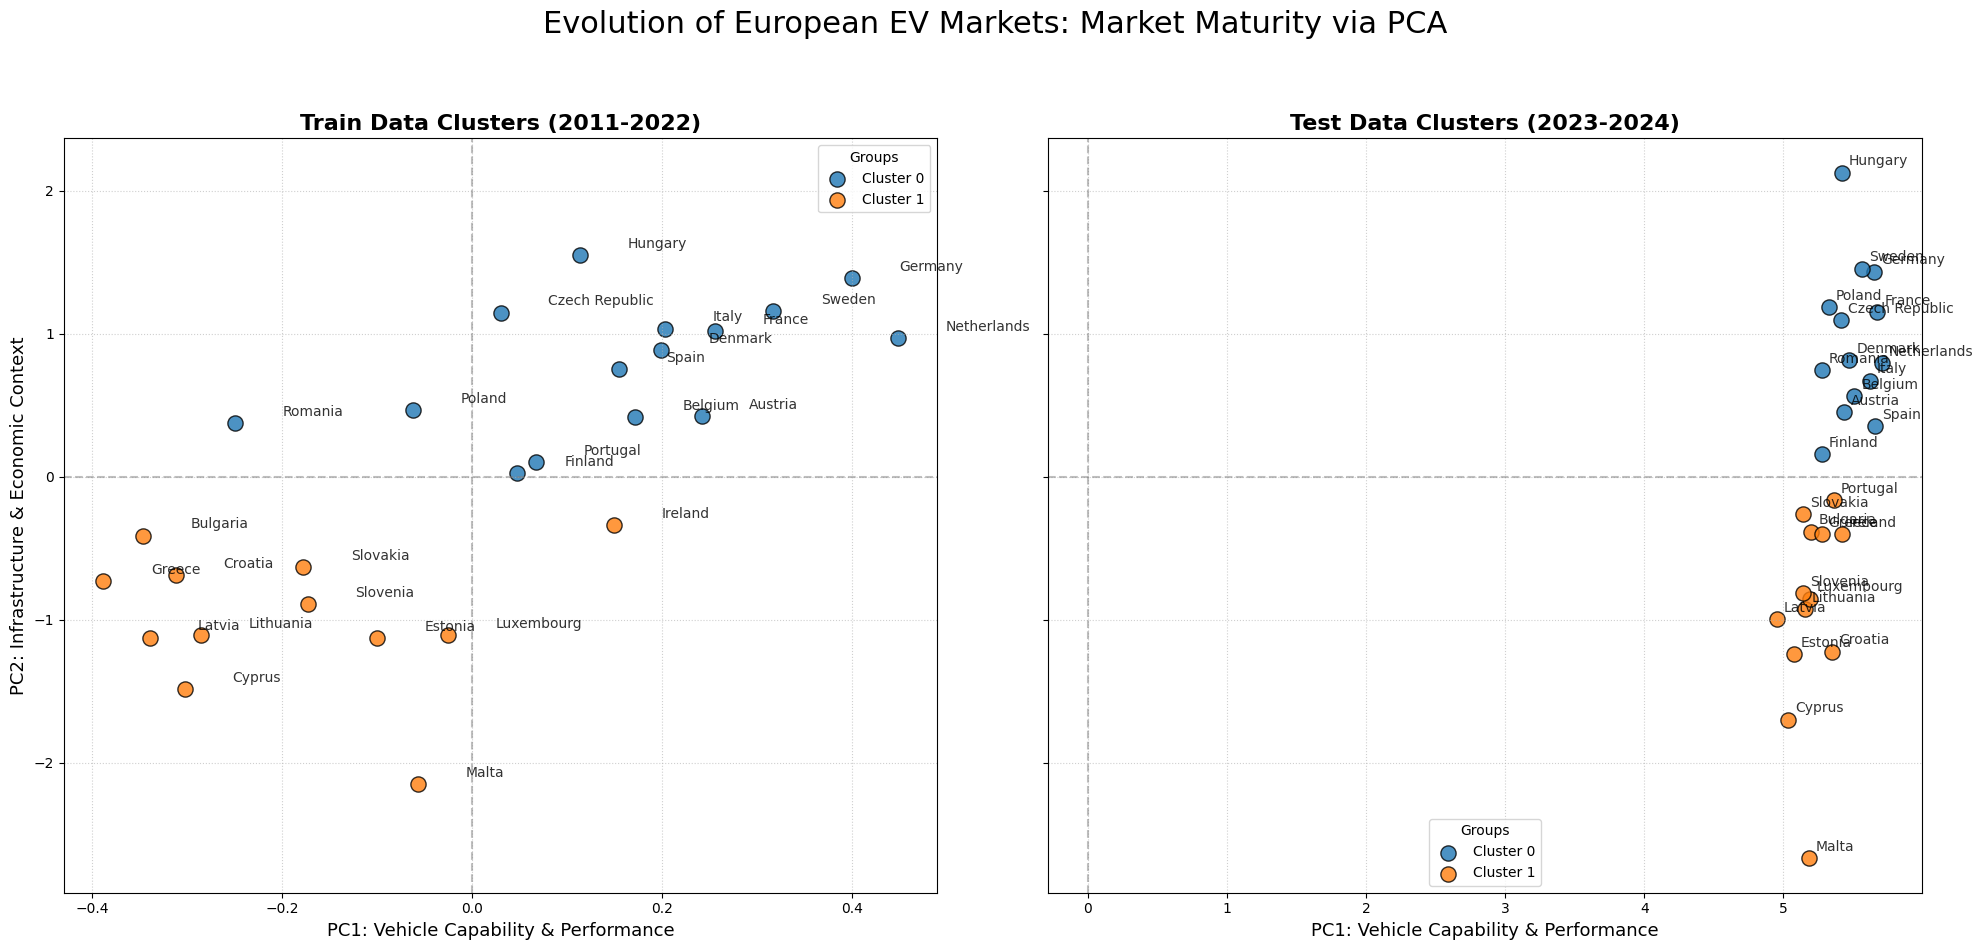

In [146]:
# Visualization Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), sharey=True, dpi=100)

# Train Data: 2011-2022
for cluster in [0, 1]:
    subset = pre_plot_data[pre_plot_data['Cluster'] == cluster]
    ax1.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', s=120, edgecolors='black', alpha=0.8)

# Add country labels for Train data
for country in pre_plot_data.index:
    row = pre_plot_data.loc[country]
    ax1.text(row['PC1'] + 0.05, row['PC2'] + 0.05, country, fontsize=10, alpha=0.8)

ax1.set_title('Train Data Clusters (2011-2022)', fontsize=16, fontweight='bold')
ax1.set_xlabel('PC1: Vehicle Capability & Performance', fontsize=13)
ax1.set_ylabel('PC2: Infrastructure & Economic Context', fontsize=13)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Groups")

# Test Data: 2023-2024
for cluster in [0, 1]:
    subset = post_plot_data[post_plot_data['Cluster'] == cluster]
    ax2.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', s=120, edgecolors='black', alpha=0.8)

# Add country labels for Test data
for country in post_plot_data.index:
    row = post_plot_data.loc[country]
    ax2.text(row['PC1'] + 0.05, row['PC2'] + 0.05, country, fontsize=10, alpha=0.8)

ax2.set_title('Test Data Clusters (2023-2024)', fontsize=16, fontweight='bold')
ax2.set_xlabel('PC1: Vehicle Capability & Performance', fontsize=13)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(title="Groups")

plt.suptitle('Evolution of European EV Markets: Market Maturity via PCA', fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

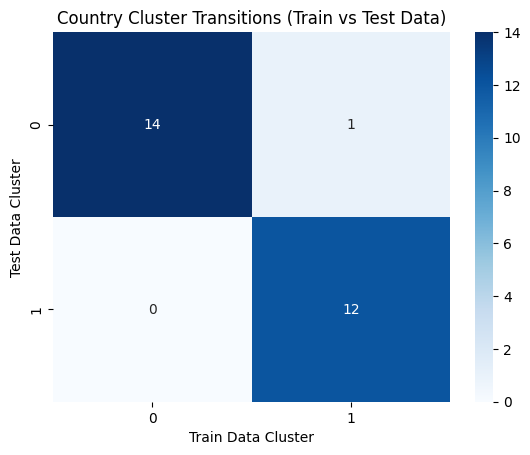

In [147]:
# Heatmap to visualize cluster transitions
ct = pd.crosstab(cluster_compare['Train_Cluster'], cluster_compare['Test_Cluster'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Country Cluster Transitions (Train vs Test Data)')
plt.xlabel('Train Data Cluster')
plt.ylabel('Test Data Cluster')
plt.show()

## 2. DBSCAN

**Parameters:**
1. eps=1.2: A point is a neighbor if the distance is <= 1.2
2. min_samples=2: A cluster needs at least 2 countries to exist

In [148]:
# Train clustering by inititalising the clusters and fitiing the model on the pca averages
dbscan_pre = DBSCAN(eps=0.8, min_samples=2)
pre_plot_data['DBSCAN_Cluster'] = dbscan_pre.fit_predict(X_pre_pca)

# Test clustering by inititalising the clusters and fitiing the model on the pca averages
dbscan_post = DBSCAN(eps=0.8, min_samples=2)
post_plot_data['DBSCAN_Cluster'] = dbscan_post.fit_predict(X_post_pca)

In [149]:
print("Train Cluster Characteristics:")
pre_characteristics = pre_plot_data.groupby('DBSCAN_Cluster')[['PC1', 'PC2', 'PC3']].mean()
display(pre_characteristics)

print("Test Cluster Characteristics:")
post_characteristics = post_plot_data.groupby('DBSCAN_Cluster')[['PC1', 'PC2', 'PC3']].mean()
display(post_characteristics)

Train Cluster Characteristics:


,PC1,PC2,PC3
DBSCAN_Cluster,,,
-1,-0.056793,-2.147544,0.896573
0,0.001460,0.079975,-0.043363


Test Cluster Characteristics:


,PC1,PC2,PC3
DBSCAN_Cluster,,,
-1,5.183498,-2.667647,0.832668
0,5.359201,0.140756,-0.119523


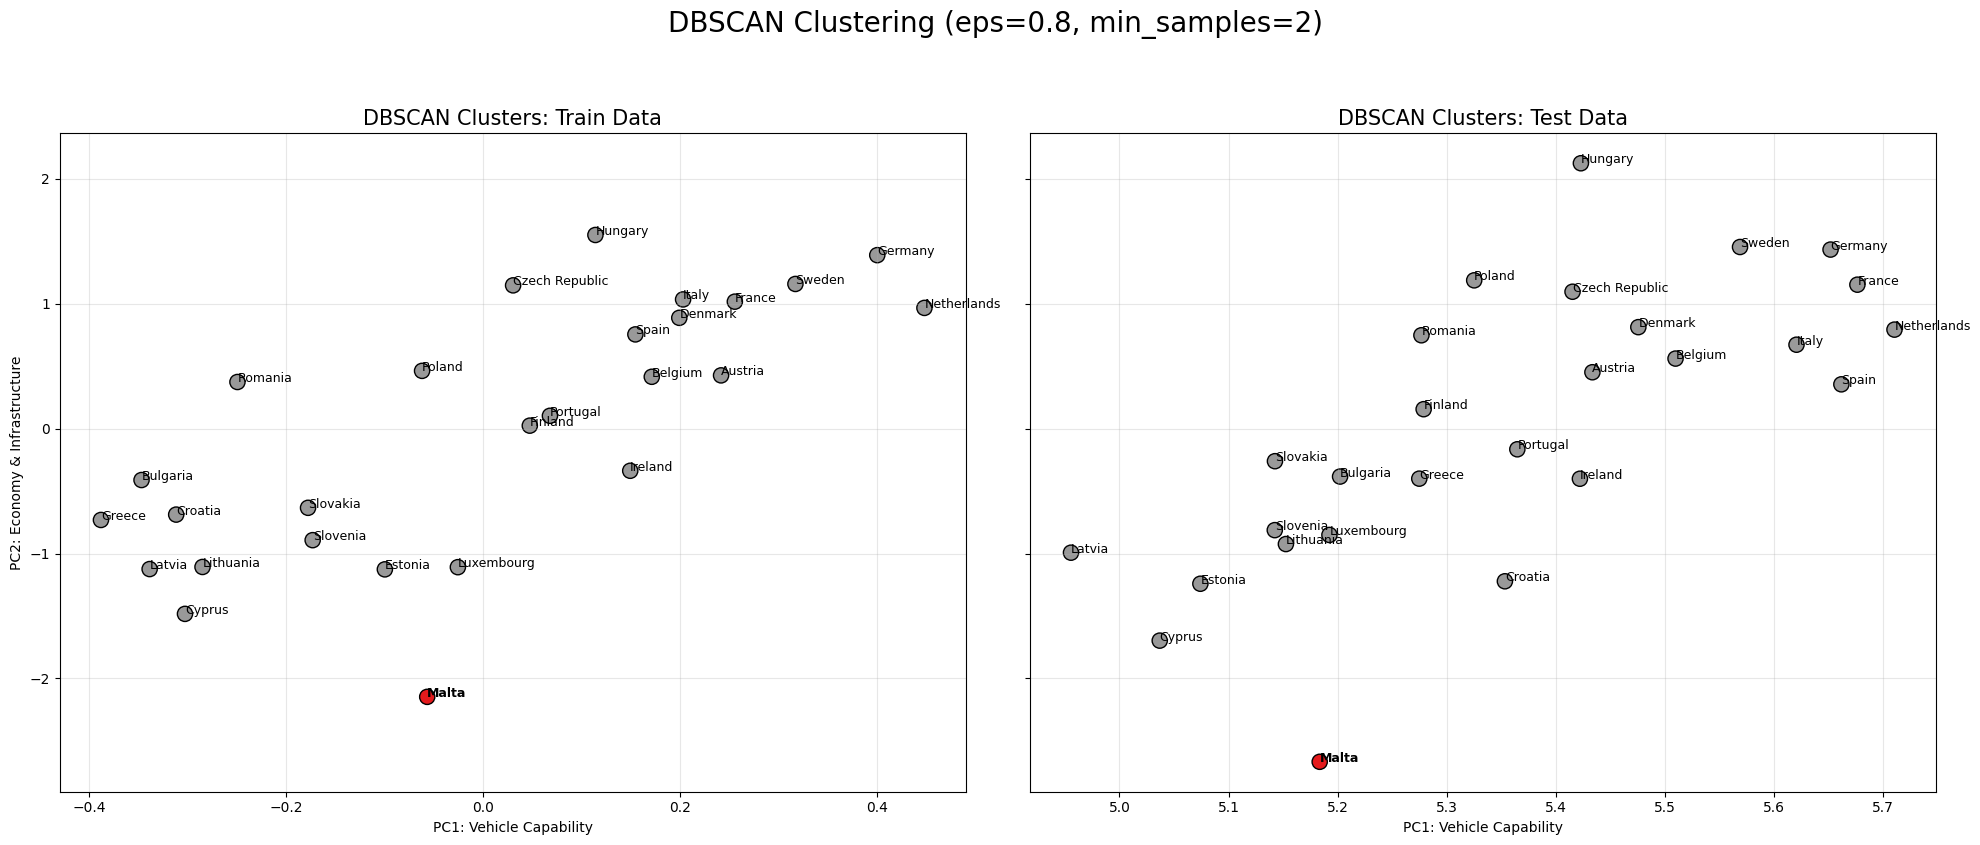

In [150]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Train visualisation
# Plot clusters and noise (-1)
scatter1 = ax1.scatter(pre_plot_data['PC1'], pre_plot_data['PC2'],
                       c=pre_plot_data['DBSCAN_Cluster'], cmap='Set1', s=120, edgecolors='black')

# Annotate Country names from the index
for country in pre_plot_data.index:
    ax1.text(pre_plot_data.loc[country, 'PC1'], pre_plot_data.loc[country, 'PC2'],
             country, fontsize=9, fontweight='bold' if country == 'Malta' else 'normal')

ax1.set_title('DBSCAN Clusters: Train Data', fontsize=15)
ax1.set_xlabel('PC1: Vehicle Capability')
ax1.set_ylabel('PC2: Economy & Infrastructure')
ax1.grid(True, alpha=0.3)

# Test visualisation
scatter2 = ax2.scatter(post_plot_data['PC1'], post_plot_data['PC2'],
                       c=post_plot_data['DBSCAN_Cluster'], cmap='Set1', s=120, edgecolors='black')

# Annotate Country names
for country in post_plot_data.index:
    ax2.text(post_plot_data.loc[country, 'PC1'], post_plot_data.loc[country, 'PC2'],
             country, fontsize=9, fontweight='bold' if country == 'Malta' else 'normal')

ax2.set_title('DBSCAN Clusters: Test Data', fontsize=15)
ax2.set_xlabel('PC1: Vehicle Capability')
ax2.grid(True, alpha=0.3)

# 4. Final touches
plt.suptitle(f'DBSCAN Clustering (eps=0.8, min_samples=2)', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [151]:
# Merge Pre and Post COVID results on the Country index
dbscan_comparison = pre_plot_data[['DBSCAN_Cluster']].merge(
    post_plot_data[['DBSCAN_Cluster']],
    left_index=True,
    right_index=True,
    suffixes=('_Train', '_Test')
)

In [152]:
# Countries that changed clusters
dbscan_changed = dbscan_comparison[dbscan_comparison['DBSCAN_Cluster_Train'] != dbscan_comparison['DBSCAN_Cluster_Test']]
print(f"Total Countries that Changed Clusters: {len(dbscan_changed)}")
display(dbscan_changed)

Total Countries that Changed Clusters: 0


,DBSCAN_Cluster_Train,DBSCAN_Cluster_Test
Country,,


In [153]:
# Countries that were stable
dbscan_stable = dbscan_comparison[dbscan_comparison['DBSCAN_Cluster_Train'] == dbscan_comparison['DBSCAN_Cluster_Test']]
print(f"Total Stable Countries: {len(dbscan_stable)}")
display(dbscan_stable)

Total Stable Countries: 27


,DBSCAN_Cluster_Train,DBSCAN_Cluster_Test
Country,,
Austria,0,0
Belgium,0,0
Bulgaria,0,0
Croatia,0,0
Cyprus,0,0
Czech Republic,0,0
Denmark,0,0
Estonia,0,0
Finland,0,0


## For Geopandas Visualisation

In [154]:
# Read Europe shapefile from GeoJSON (countries only)
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)

print(world.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry'], dtype='object')


In [155]:
# List of European countries
europe_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"
]

# Replace 'name' with whatever column actually contains country names
europe = world[world['name'].isin(europe_countries)]

In [156]:
geo_data = europe.merge(dataset, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [157]:
print(geo_data.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country',
       'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)'],
      dtype='object')


In [158]:
# Create Train Data summary
# We reset the index to turn 'Country' into a column and rename 'Cluster' to 'KMeans_Cluster'
pre_covid_summary = pre_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'DBSCAN_Cluster', 'KMeans_Cluster']]

# Create Test Data summary
post_covid_summary = post_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'DBSCAN_Cluster', 'KMeans_Cluster']]

print("Train Data K-Means and DBSCAN")
display(pre_covid_summary.head())
print()
print("Test Data K-Means and DBSCAN")
display(post_covid_summary.head())

Train Data K-Means and DBSCAN


,Country,DBSCAN_Cluster,KMeans_Cluster
0,Austria,0,0
1,Belgium,0,0
2,Bulgaria,0,1
3,Croatia,0,1
4,Cyprus,0,1



Test Data K-Means and DBSCAN


,Country,DBSCAN_Cluster,KMeans_Cluster
0,Austria,0,0
1,Belgium,0,0
2,Bulgaria,0,1
3,Croatia,0,1
4,Cyprus,0,1


In [159]:
# Create a fresh copy of your main dataset
dataset_clusters = dataset.copy()

# Merge Train clusters
dataset_clusters = dataset_clusters.merge(
    pre_covid_summary,
    on='Country',
    how='left'
).rename(columns={'DBSCAN_Cluster': 'DBSCAN_Train', 'KMeans_Cluster': 'KMeans_Train'})

# Merge Test clusters
dataset_clusters = dataset_clusters.merge(
    post_covid_summary,
    on='Country',
    how='left'
).rename(columns={'DBSCAN_Cluster': 'DBSCAN_Test', 'KMeans_Cluster': 'KMeans_Test'})

print("Merging complete. Columns in dataset_clusters:")
print(dataset_clusters.columns)

Merging complete. Columns in dataset_clusters:
Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)', 'DBSCAN_Train', 'KMeans_Train',
       'DBSCAN_Test', 'KMeans_Test'],
      dtype='object')


In [160]:
geo_data = europe.merge(dataset_clusters, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [161]:
print(geo_data.columns.tolist())

['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country', 'Year', 'BEV Percentage (Total Number Of Registrations)', 'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points', 'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)', 'Log_BEV Percentage (Total Number Of Registrations)', 'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)', 'YJ_Purchase price (EUR)', 'DBSCAN_Train', 'KMeans_Train', 'DBSCAN_Test', 'KMeans_Test']


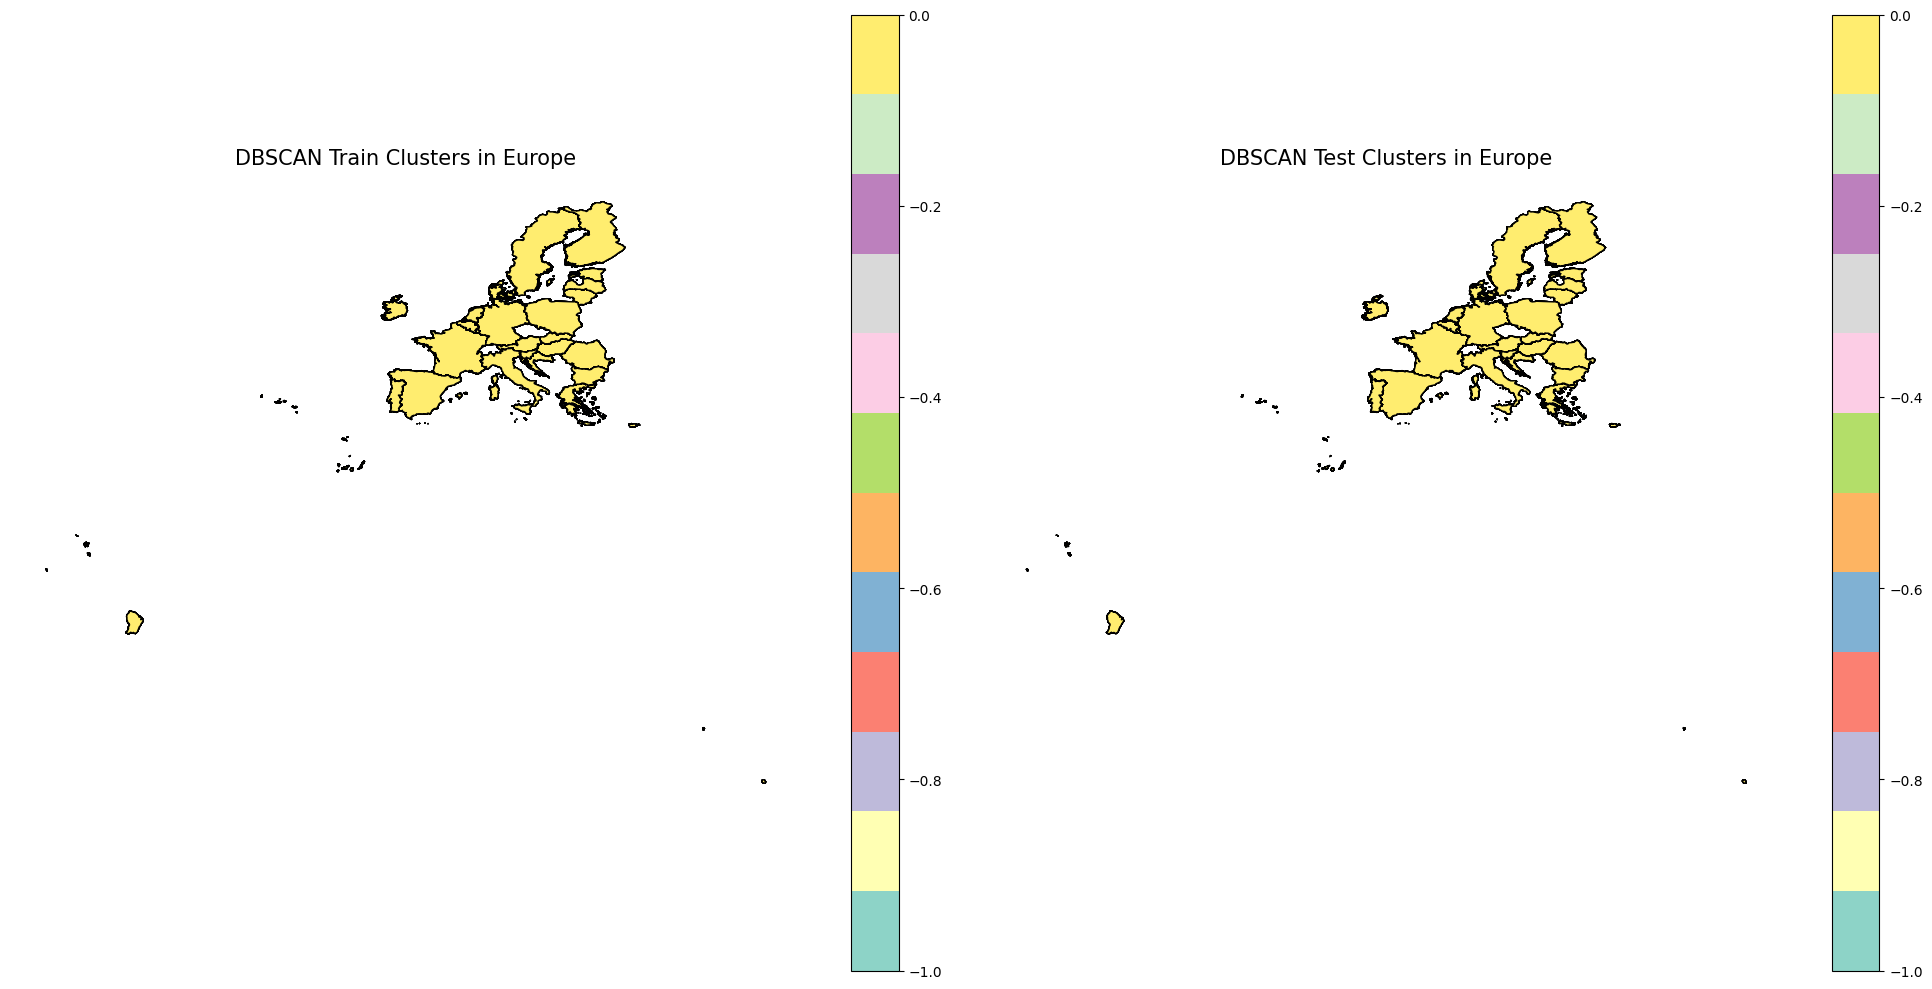

In [162]:
# DBSCAN: Train and Test-COVID
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Train Data
geo_data.plot(column='DBSCAN_Train',
              cmap='Set3',
              legend=True,
              ax=axes[0],
              edgecolor='black',
              missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
axes[0].set_title("DBSCAN Train Clusters in Europe", fontsize=15)
axes[0].axis('off')

# Plot Test Data
geo_data.plot(column='DBSCAN_Test',
              cmap='Set3',
              legend=True,
              ax=axes[1],
              edgecolor='black',
              missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
axes[1].set_title("DBSCAN Test Clusters in Europe", fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

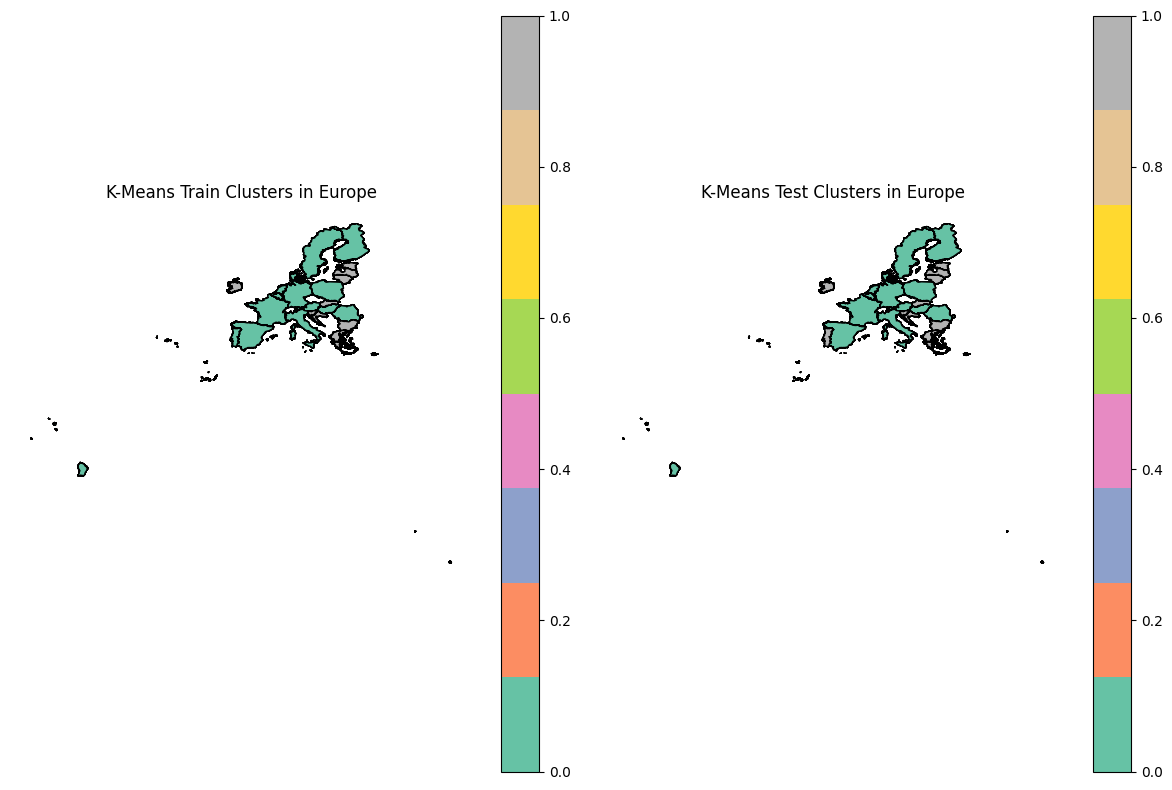

In [163]:
# K-Means: Train and Test-COVID

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

geo_data.plot(column='KMeans_Train', cmap='Set2', legend=True, ax=axes[0], edgecolor='black')
axes[0].set_title("K-Means Train Clusters in Europe")
axes[0].axis('off')

geo_data.plot(column='KMeans_Test', cmap='Set2', legend=True, ax=axes[1], edgecolor='black')
axes[1].set_title("K-Means Test Clusters in Europe")
axes[1].axis('off')

plt.tight_layout()
plt.show()